# Batch-wise causarray Analysis — Replogle-E-K562

This tutorial demonstrates the **batch fitting workflow** of `causarray` on a
subset of the Replogle et al. 2022 genome-wide CRISPRi screen in K562 cells
([Replogle et al. 2022, Cell](https://doi.org/10.1016/j.cell.2022.05.013)).

**Dataset (tutorial subset)**
- Full dataset: 309 915 cells × 8 563 genes, 2 021 perturbations
- Tutorial subset: top-200 most-abundant perturbations + 2 000 ctrl cells
  → **79 865 cells**, created by `prep_tutorial_data.py`

**Why batch fitting?**  
Running `fit_gcate` on 79 865 cells with 200 perturbations simultaneously
would require fitting a GLM with 201 treatment columns, which is both
numerically difficult and memory-intensive. `gcate_lfc_batch` avoids this
by pairing each batch of 15 perturbations with a fixed pool of control cells,
bounding peak memory to one batch at a time regardless of total pert count.

**Pipeline overview**
```
replogle_subset.h5ad
      |
      v  prep_causarray_data
   Y, A, X                  (count matrix, treatment indicators, covariates)
      |
      v  gcate_lfc_batch
   df_res                   (tau, std, stat, pvalue, padj per gene x pert)
      |
      v  visualization
   volcano, discovery bar chart
```


In [ ]:
import sys
sys.path.insert(0, '../../..')

import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc

from causarray import prep_causarray_data, gcate_lfc_batch
from causarray.gcate import plot_r

import causarray
print('causarray version:', causarray.__version__)


causarray version: 0.0.6


## 1. Load data

The subset was prepared by `prep_tutorial_data.py`. It contains the 200
perturbations with the most cells plus a random sample of 2 000 ctrl
(`non-targeting`) cells.


In [6]:
adata = sc.read_h5ad('replogle_subset.h5ad')
print(adata)

CTRL_LABEL = adata.uns['ctrl_label']   # 'non-targeting'
PERT_COL   = adata.uns['pert_col']     # 'gene'

vc = adata.obs[PERT_COL].value_counts()
print(f'\nCtrl cells  : {vc[CTRL_LABEL]}')
print(f'Pert cells  : {vc.drop(CTRL_LABEL).sum():,}  across {len(vc) - 1} perturbations')
print(f'Cells/pert  : median {vc.drop(CTRL_LABEL).median():.0f}, '
      f'range {vc.drop(CTRL_LABEL).min()}-{vc.drop(CTRL_LABEL).max()}')


AnnData object with n_obs × n_vars = 79865 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    uns: 'ctrl_label', 'pert_col'

Ctrl cells  : 2000
Pert cells  : 77,865  across 200 perturbations
Cells/pert  : median 346, range 273-1996


## 2. Prepare causarray inputs


In [7]:
Y_raw = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
Y = pd.DataFrame(Y_raw, columns=adata.var_names.tolist())
del Y_raw

A = (pd.get_dummies(adata.obs[PERT_COL].astype(str), drop_first=False)
       .drop(columns=[CTRL_LABEL]))

Y, A, X, X_A = prep_causarray_data(Y, A)

print(f'Y : {Y.shape}  (cells x genes)')
print(f'A : {A.shape}  (cells x perturbations)')
print(f'X : {X.shape}  X_A : {X_A.shape}')


Y : (79865, 8563)  (cells x genes)
A : (79865, 200)  (cells x perturbations)
X : (79865, 1)  X_A : (79865, 2)


## 3. Number of latent factors

We select `r` using the JIC criterion computed by `estimate_r`. The
pre-computed results are loaded from `replogle-r.csv` (generated by
`estimate_r_replogle.py`; re-run that script to reproduce them).

> **Why estimate `r` on control cells?**  
> `estimate_r` fits GCATE internally, which is expensive at full dataset scale
> (79 865 cells). The latent factors capture **confounding variation** that is
> present in the baseline (control) transcriptome, so a ctrl-priority subsample
> is both much faster and statistically equivalent to using all cells.  
> `estimate_r_replogle.py` uses 2 000 ctrl + 20 × ≤200 pert cells for this reason.  
> You can replicate this with the `max_cells` argument:
> ```python
> df_r = estimate_r(Y, X, A, r_values, family='nb', max_cells=6000)
> ```
> `estimate_r` will automatically prioritise control cells when subsampling.


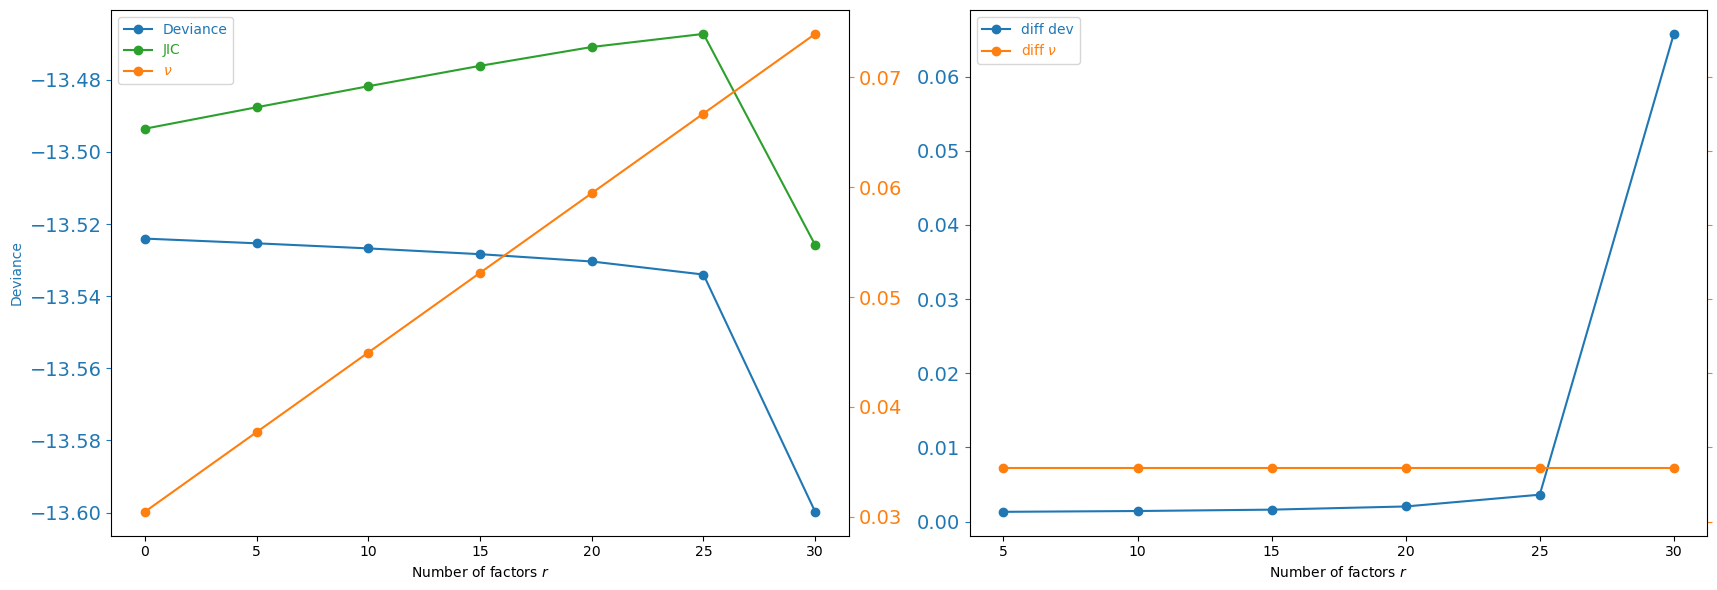


Selected r = 30  (min JIC)
 r   deviance       nu        JIC
 0 -13.524045 0.030448 -13.493596
 5 -13.525350 0.037698 -13.487652
10 -13.526765 0.044947 -13.481817
15 -13.528364 0.052197 -13.476167
20 -13.530392 0.059447 -13.470945
25 -13.534008 0.066696 -13.467311
30 -13.599773 0.073946 -13.525827


In [8]:
df_r = pd.read_csv('replogle-r.csv')
fig = plot_r(df_r)
plt.tight_layout()
plt.show()

best_r = int(df_r.loc[df_r['JIC'].idxmin(), 'r'])
print(f'\nSelected r = {best_r}  (min JIC)')
print(df_r.to_string(index=False))


## 4. Batch fitting with `gcate_lfc_batch`

Key parameters:

| Parameter | Value | Effect |
|-----------|-------|--------|
| `batch_size` | 15 | ~15 perts processed per GCATE call |
| `max_cells` | 2000 | <= 2000 pert cells per batch (ctrl added on top) |
| `n_ctrl` | 2000 | Fixed ctrl subsample shared across all batches |
| `cache_path` | `'replogle_results.h5'` | Resume from disk if interrupted |

With 200 perturbations and `batch_size=15`, `gcate_lfc_batch` internally
computes `n_batches = ceil(200 / 15) = 14` and then calls
`numpy.array_split` to distribute the remainder evenly, giving
**4 batches of 15 and 10 batches of 14** — no tiny tail batch.
Each batch has at most 2000 ctrl + 2000 pert cells = 4000 cells.


In [9]:
R = best_r

t0 = time.perf_counter()
df_res = gcate_lfc_batch(
    Y, X, A, R,
    W_A=X_A,
    batch_size=15,
    max_cells=2000,
    n_ctrl=2000,
    family='nb',
    cache_path='replogle_results.h5',
    random_state=0,
    verbose=True,
    gcate_kwargs=dict(
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
    ),
)
t_total = time.perf_counter() - t0

print(f'\nTotal wall time: {t_total/60:.1f} min')
print(f'Result shape   : {df_res.shape}')
df_res.head()


'Pre-estimating dispersion on ctrl cell subsample...'


GCATE batches:   0%|          | 0/14 [00:00<?, ?batch/s]

'Fitting GCATE (step 1)...'
'Fitting GCATE (step 2)...'


GCATE batches:   7%|▋         | 1/14 [02:23<31:11, 143.93s/batch]

'Batch 1/14: 15 perts, 4000 cells, 143.9s  (avg 143.9s/batch, ETA 0.5h)'
'Fitting GCATE (step 1)...'
'Fitting GCATE (step 2)...'


...

100%|██████████| 14/14 [00:15<00:00,  1.11s/it]


'Estimating LFC...'
{'a': 14, 'd': 31, 'd_A': 32, 'estimands': 'LFC', 'n': 4000, 'p': 8563}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([ 0.00170334, -0.004485  ,  0.00183328, ...,  0.00178951,
        0.00073638, -0.00187221], shape=(4000,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
'Fit outcome models...'
'Fitting nb GLM (fast)...'
'Estimating AIPW mean...'


100%|██████████| 14/14 [00:15<00:00,  1.13s/it]



Total wall time: 217.5 min
Result shape   : (1712600, 11)


,gene_names,tau,std,stat,rej,pvalue,padj,pvalue_emp_null_adj,padj_emp_null_adj,trt,batch
0,LINC01409,-0.267417,0.582597,-0.459008,0.0,0.647247,0.902419,0.710758,0.984769,AATF,0
1,LINC01128,-0.417859,2.603416,-0.160504,0.0,0.872828,0.946645,0.454847,0.980170,AATF,0
2,NOC2L,-0.043346,0.076478,-0.566783,0.0,0.572048,0.877640,0.814469,0.989977,AATF,0
3,KLHL17,-0.249348,0.576602,-0.432443,0.0,0.666384,0.910016,0.685930,0.983432,AATF,0
4,HES4,-0.314250,0.279536,-1.124184,0.0,0.263418,0.747352,0.638143,0.980170,AATF,0


## 5. Results

### 5.1 Discovery summary


In [10]:
FDR = 0.05
sig = df_res[df_res['padj'] < FDR]

print(f'Significant (padj < {FDR}): {len(sig):,} gene x pert pairs')
print(f'  Perturbations with >= 1 hit: {sig["trt"].nunique()}')
print(f'  Unique genes affected      : {sig["gene_names"].nunique():,}')

disc_per_pert = sig.groupby('trt').size().sort_values(ascending=False)
print(f'\nTop-10 perts by discovery count:')
print(disc_per_pert.head(10).to_string())


Significant (padj < 0.05): 222,090 gene x pert pairs
  Perturbations with >= 1 hit: 173
  Unique genes affected      : 8,131

Top-10 perts by discovery count:
trt
KIF11      4932
RPL3       4858
DONSON     4539
QARS       4084
SLC39A9    4016
EIF3H      3926
PMPCB      3894
NUP205     3603
HSPA5      3522
SSRP1      3425


### 5.2 Volcano plot (all perturbations combined)


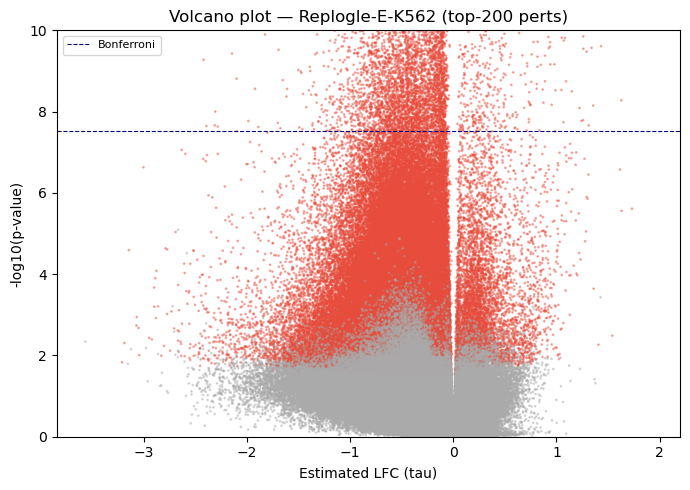

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = np.where(df_res['padj'] < FDR, '#e74c3c', '#aaaaaa')
ax.scatter(
    df_res['tau'], -np.log10(df_res['pvalue'].clip(1e-300)),
    c=colors, s=1, alpha=0.4, rasterized=True,
)
ax.axhline(-np.log10(0.05 / len(df_res)), color='navy', lw=0.8, ls='--',
           label='Bonferroni')
ax.set_ylim(0, 10)
ax.set_xlabel('Estimated LFC (tau)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — Replogle-E-K562 (top-200 perts)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Discovery count per perturbation


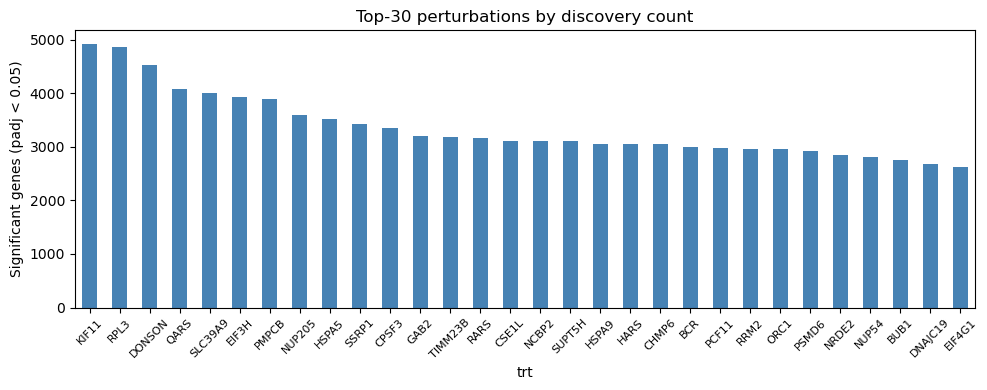

In [14]:
top_n = 30
top_disc = disc_per_pert.head(top_n)

fig, ax = plt.subplots(figsize=(10, 4))
top_disc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_ylabel(f'Significant genes (padj < {FDR})')
ax.set_title(f'Top-{top_n} perturbations by discovery count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()
